# Лабораторная работа №2
**Предмет:** язык Python для анализа данных  
**ФИО:** Филиппов Владимир Леонидович   
**Группа:** K3339   
**ИСУ:** 292209

## Цель работы
- Научиться работать с NumPy-массивами.
- Закрепить срезы, оси, broadcasting и простые операции над массивами.
- Понять разницу между циклами Python и векторизацией NumPy на примере kNN.

## Используемые библиотеки
- numpy
- matplotlib
- (опционально) pillow для чтения изображения

## Часть 1 - Изображение как NumPy-массив

### Исходные данные
- Изображение загружается из файла `image.jpg`.
- Если файла нет или Pillow не установлен, создается случайный массив `uint8` формы (H, W, 3).

### 1) Форма массива изображения
- Цветное изображение в NumPy имеет форму:
  - (H, W, 3)
- Где:
  - H - высота
  - W - ширина
  - 3 - каналы RGB (красный, зеленый, синий)

### 2) Задание 2.1 - Выделение каналов
- Созданы 3 массива:
  - только красный канал (G=0, B=0)
  - только зеленый канал (R=0, B=0)
  - только синий канал (R=0, G=0)
- Результаты выводятся через `plt.imshow()`.

### 3) Задание 3.1 - Grayscale
- Использована формула:
  - gray = 0.299*R + 0.587*G + 0.114*B
- Результат приведен к типу `uint8` и показан как серое изображение.

### 4) Задание 4.1 - Уменьшение в 2 раза
- Применен срез:
  - small = img[::2, ::2]
- Это простой даунсэмплинг (берем каждый второй пиксель).

### 5) Задание 5.1 - Затирание прямоугольника
- Выбран прямоугольник по координатам:
  - y1:y2 и x1:x2
- Пиксели в области заменены на черный цвет [0, 0, 0].

### 6) Задание 6.1-6.3 - Перевороты и поворот
- Горизонтальный переворот:
  - np.flip(img, axis=1)
- Вертикальный переворот:
  - np.flip(img, axis=0)
- Поворот на 180:
  - np.flip(img, axis=(0, 1))

### 7) Задание 7.1 - Broadcasting (сделать "теплее")
- Создан фильтр:
  - filter = [50, 0, 0]
- Прибавлен к изображению (broadcasting по последней оси).
- Применен `np.clip` для ограничения 0..255.

### 8) Задание 8.1 - Градиентная маска
- Создан градиент по высоте:
  - gradient формы (H, 1, 1)
- Смешаны два изображения:
  - оригинал и инверсия (255 - img)
- Получен плавный переход сверху вниз.

## Часть 2 - kNN: чистый Python и NumPy

### Подготовка данных
- Генерируется обучающая выборка X размера (n, 3) из нормального распределения.
- Метки классов y создаются правилом:
  - класс 1, если сумма координат > 0, иначе класс 0

### Реализация 1 - чистый Python
- Расстояния считаются циклом по всем точкам и по всем координатам.
- Используется сортировка списка расстояний.
- Берутся k ближайших и выполняется голосование.

### Реализация 2 - NumPy
- Расстояния считаются векторно:
  - np.linalg.norm(X_train - x_test, axis=1)
- Индексы ближайших:
  - np.argsort(dists)[:k]
- Голосование:
  - среднее по меткам k соседей.

### Анализ результатов
- NumPy вариант работает быстрее, так как использует векторные операции и вычисляет расстояния без циклов Python.
- Чувствительность к k:
  - при малом k (например 1) результат более "шумный" и может меняться от выбросов
  - при большем k результат стабильнее, но может "сглаживать" границы классов

### Масштабирование
- При увеличении n (1000 -> 10000 -> 100000) время чистого Python растет очень сильно.
- NumPy растет медленнее и остается пригодным для больших n.

## Вывод
- NumPy удобен для работы с массивами и изображениями.
- Broadcasting позволяет менять каналы простыми операциями без циклов.
- Векторизация NumPy дает заметный выигрыш по времени по сравнению с циклами Python, особенно на больших данных.

## Код - Часть 1: изображение как NumPy-массив
Ниже код вставлен блоками между заданиями, чтобы было удобно читать и защищать.

In [1]:
# Установка (если нужно) - в Colab можно раскомментировать
# !pip -q install numpy matplotlib pillow

import os
import numpy as np
import matplotlib.pyplot as plt

# Пытаемся подключить Pillow (для чтения image.jpeg / image.jpg)
try:
    from PIL import Image
    PIL_OK = True
except Exception:
    PIL_OK = False

print("Pillow доступен:", PIL_OK)
print("Текущая папка:", os.getcwd())

Pillow доступен: True
Текущая папка: /Users/vladimir/Documents/python_for_data_analysis/lab2


In [1]:
def load_image_or_random(names=("image.jpeg", "image.jpg", "image.png"), h=256, w=256):
    """Загружает изображение по одному из имен. Если не получилось - создает случайную картинку."""
    if PIL_OK:
        for name in names:
            if os.path.exists(name):
                img = Image.open(name).convert("RGB")
                arr = np.array(img, dtype=np.uint8)
                print("Загружено изображение:", name, "| shape:", arr.shape, "| dtype:", arr.dtype)
                return arr
    # fallback
    print("Файл изображения не найден или Pillow недоступен - создаю случайную картинку.")
    return np.random.randint(0, 256, size=(h, w, 3), dtype=np.uint8)

def show(img, title=""):
    plt.figure(figsize=(6, 4))
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

### Исходные данные
- Пытаемся загрузить `image.jpeg` (или `image.jpg` / `image.png`).
- Если файла нет или Pillow не установлен - создается случайный массив `uint8`.

Загружено изображение: image.jpeg | shape: (720, 1440, 3) | dtype: uint8


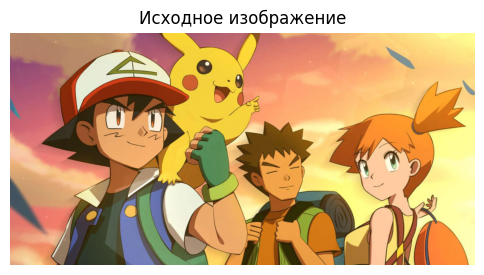

In [3]:
img = load_image_or_random()
show(img, "Исходное изображение")

### 1) Форма массива изображения

In [4]:
print("Форма изображения (H, W, 3):", img.shape)
print("Тип данных (dtype):", img.dtype)

Форма изображения (H, W, 3): (720, 1440, 3)
Тип данных (dtype): uint8


### 2) Выделение каналов RGB (только красный / зеленый / синий)

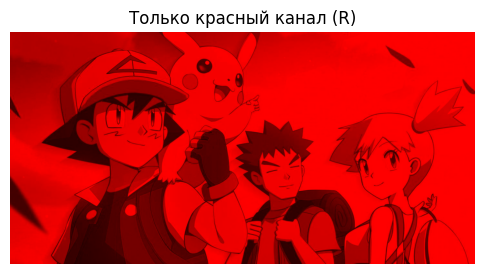

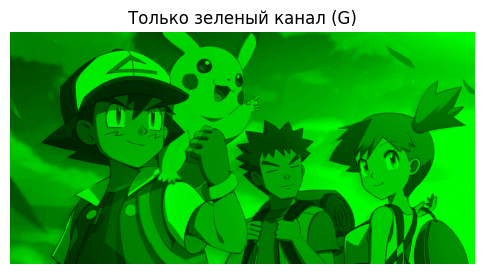

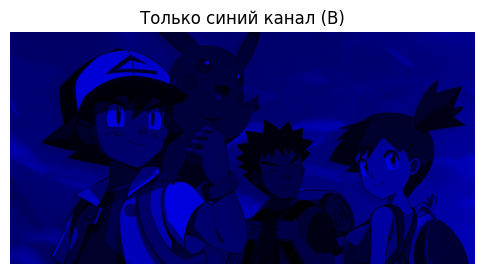

In [5]:
red = img.copy()
red[:, :, 1] = 0
red[:, :, 2] = 0

green = img.copy()
green[:, :, 0] = 0
green[:, :, 2] = 0

blue = img.copy()
blue[:, :, 0] = 0
blue[:, :, 1] = 0

show(red, "Только красный канал (R)")
show(green, "Только зеленый канал (G)")
show(blue, "Только синий канал (B)")

### 3) Grayscale (оттенки серого)

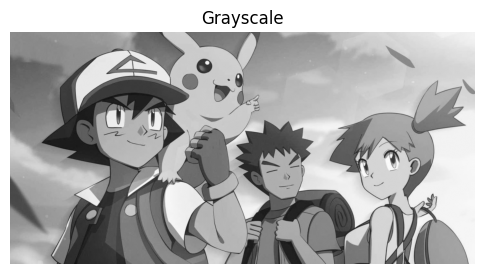

In [6]:
# Формула яркости
gray = (0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]).astype(np.uint8)
show(gray, "Grayscale")

### 4) Уменьшение изображения в 2 раза (простое)

Форма уменьшенного изображения: (360, 720, 3)


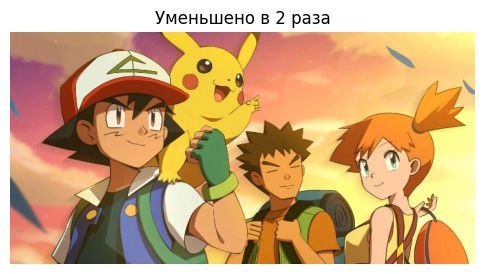

In [7]:
small = img[::2, ::2, :]
print("Форма уменьшенного изображения:", small.shape)
show(small, "Уменьшено в 2 раза")

### 5) Затирание прямоугольника

Прямоугольник затерт в диапазонах: (180, 360) (360, 720)


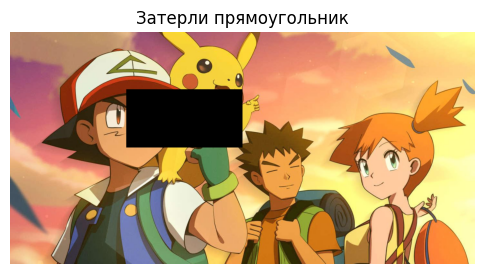

In [8]:
masked = img.copy()
H, W = masked.shape[:2]

# Прямоугольник берем относительно размеров картинки, чтобы не выйти за границы
y1, y2 = H // 4, H // 2
x1, x2 = W // 4, W // 2

masked[y1:y2, x1:x2, :] = 0
print("Прямоугольник затерт в диапазонах:", (y1, y2), (x1, x2))
show(masked, "Затерли прямоугольник")

### 6) Перевороты и поворот

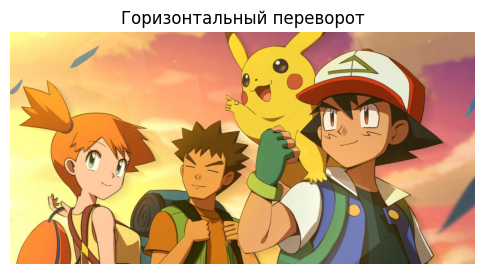

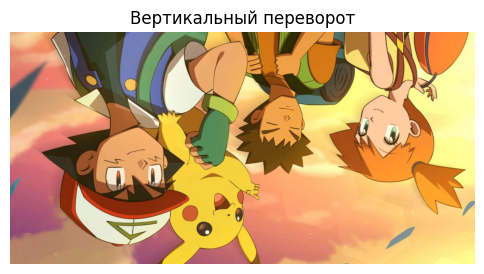

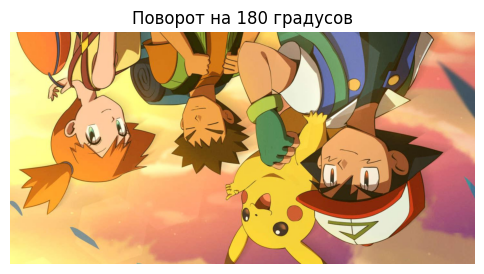

In [9]:
flip_h = np.flip(img, axis=1)          # горизонтальный
flip_v = np.flip(img, axis=0)          # вертикальный
rot180 = np.flip(img, axis=(0, 1))     # 180 градусов

show(flip_h, "Горизонтальный переворот")
show(flip_v, "Вертикальный переворот")
show(rot180, "Поворот на 180 градусов")

### 7) Broadcasting - сделать изображение 'теплее'

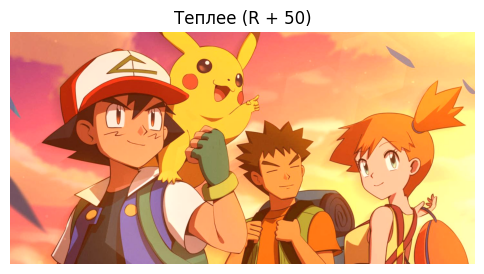

In [10]:
warm = img.astype(np.int16) + np.array([50, 0, 0], dtype=np.int16)  # +50 к красному
warm = np.clip(warm, 0, 255).astype(np.uint8)
show(warm, "Теплее (R + 50)")

### 8) Градиентная маска - плавное смешивание оригинала и инверсии

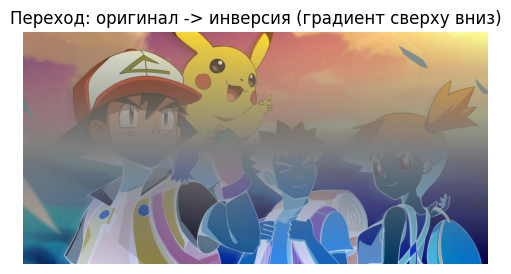

In [11]:
inverted = 255 - img

H = img.shape[0]
gradient = np.linspace(0, 1, H, dtype=np.float32).reshape(H, 1, 1)  # (H,1,1)

blended = (img.astype(np.float32) * (1 - gradient) + inverted.astype(np.float32) * gradient)
blended = np.clip(blended, 0, 255).astype(np.uint8)

show(blended, "Переход: оригинал -> инверсия (градиент сверху вниз)")

## Код - Часть 2: kNN (чистый Python и NumPy)
Ниже простая реализация kNN и сравнение скорости.

In [12]:
import time

def make_data(n=5000, dim=3, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, dim)).astype(np.float64)
    y = (X.sum(axis=1) > 0).astype(np.int64)  # класс 1 если сумма координат > 0, иначе 0
    q = rng.normal(size=(dim,)).astype(np.float64)  # тестовая точка
    return X, y, q

def knn_python(X, y, q, k=5):
    # квадрат расстояния (без sqrt - быстрее, порядок не меняется)
    dist2 = []
    for i in range(len(X)):
        s = 0.0
        for j in range(X.shape[1]):
            d = X[i, j] - q[j]
            s += d * d
        dist2.append((s, y[i]))
    dist2.sort(key=lambda t: t[0])
    votes = [lab for _, lab in dist2[:k]]
    return 1 if (sum(votes) / k) > 0.5 else 0

def knn_numpy(X, y, q, k=5):
    diff = X - q               # broadcasting
    dist2 = np.sum(diff * diff, axis=1)
    idx = np.argpartition(dist2, k)[:k]
    return 1 if (y[idx].mean() > 0.5) else 0

def time_call(func, *args, **kwargs):
    t0 = time.perf_counter()
    res = func(*args, **kwargs)
    t1 = time.perf_counter()
    return res, (t1 - t0)

In [13]:
X, y, q = make_data(n=10000, dim=3, seed=42)

k = 5
pred_py, t_py = time_call(knn_python, X, y, q, k)
pred_np, t_np = time_call(knn_numpy, X, y, q, k)

print("kNN (Python): предсказание =", pred_py, "| время =", round(t_py, 4), "сек")
print("kNN (NumPy):  предсказание =", pred_np, "| время =", round(t_np, 4), "сек")
if t_np > 0:
    print("Ускорение NumPy примерно в", round(t_py / t_np, 1), "раз(а)")

kNN (Python): предсказание = 0 | время = 0.0552 сек
kNN (NumPy):  предсказание = 0 | время = 0.0013 сек
Ускорение NumPy примерно в 41.4 раз(а)


## Полный исходный код (src)

In [ ]:
import os
import time
import math
import numpy as np
import matplotlib.pyplot as plt

# Pillow - опционально. Если не установлен или нет файла, создадим случайный массив.
try:
    from PIL import Image
    PIL_OK = True
except Exception:
    PIL_OK = False


# Часть 1. Изображение как массив

def load_image_or_random(path="image.jpeg", h=256, w=256):
    if PIL_OK and os.path.exists(path):
        img = Image.open(path).convert("RGB")
        arr = np.array(img, dtype=np.uint8)
        return arr
    # fallback: "картинка" из случайных пикселей
    return np.random.randint(0, 256, size=(h, w, 3), dtype=np.uint8)


def show(img, title=""):
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


def task_image_ops(img):
    print("Форма изображения:", img.shape)  # (H, W, 3)

    # 2.1 Каналы
    red = img.copy()
    red[:, :, 1] = 0
    red[:, :, 2] = 0

    green = img.copy()
    green[:, :, 0] = 0
    green[:, :, 2] = 0

    blue = img.copy()
    blue[:, :, 0] = 0
    blue[:, :, 1] = 0

    show(red, "Красный канал")
    show(green, "Зеленый канал")
    show(blue, "Синий канал")

    # 3.1 Grayscale (весовое среднее)
    gray = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
    gray = gray.astype(np.uint8)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")
    plt.show()

    # 4.1 Уменьшение в 2 раза по каждой оси (даунсэмплинг срезом)
    small = img[::2, ::2]
    show(small, "Уменьшено в 2 раза")

    # 5.1 Затирание прямоугольника
    erased = img.copy()
    # координаты прямоугольника (пример)
    y1, y2 = 60, 140
    x1, x2 = 80, 180
    erased[y1:y2, x1:x2] = [0, 0, 0]
    show(erased, "Затерли прямоугольник")

    # 6.1-6.3 Перевороты
    flip_h = np.flip(img, axis=1)   # горизонтально
    flip_v = np.flip(img, axis=0)   # вертикально
    rot180 = np.flip(img, axis=(0, 1))  # 180 градусов
    show(flip_h, "Горизонтальный переворот")
    show(flip_v, "Вертикальный переворот")
    show(rot180, "Поворот на 180")

    # 7.1 Broadcasting - "теплее" (прибавляем к красному каналу)
    filt = np.array([50, 0, 0], dtype=np.int16)          # (3,)
    warmer = img.astype(np.int16) + filt                  # расширение (broadcasting)
    warmer = np.clip(warmer, 0, 255).astype(np.uint8)     # ограничиваем 0..255
    show(warmer, "Теплее (R + 50)")

    # 8.1 Градиентная маска и смешивание с инверсией
    H, W = img.shape[:2]
    gradient = np.linspace(0, 1, H)[:, None, None]       # (H, 1, 1)
    inverted = 255 - img
    blended = (img * (1 - gradient) + inverted * gradient).astype(np.uint8)
    show(blended, "Переход: оригинал -> инверсия")


# Часть 2. kNN - Python vs NumPy

def make_data(n=1000, dim=3, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n, dim))
    y = (X.sum(axis=1) > 0).astype(int)
    return X, y


def knn_python(X_train, y_train, x_test, k=5):
    dists = []
    for i in range(len(X_train)):
        # евклидово расстояние
        s = 0.0
        for j in range(len(x_test)):
            s += (X_train[i][j] - x_test[j]) ** 2
        d = math.sqrt(s)
        dists.append((d, y_train[i]))

    dists.sort(key=lambda t: t[0])
    k_labels = [lab for _, lab in dists[:k]]
    # голосование
    return 1 if sum(k_labels) > (k / 2) else 0


def knn_numpy(X_train, y_train, x_test, k=5):
    dists = np.linalg.norm(X_train - x_test, axis=1)     # (n,)
    idx = np.argsort(dists)[:k]
    votes = y_train[idx]
    # если больше половины единиц - класс 1
    return int(votes.mean() > 0.5)


def time_call(fn, *args, repeats=1, **kwargs):
    t0 = time.perf_counter()
    out = None
    for _ in range(repeats):
        out = fn(*args, **kwargs)
    t1 = time.perf_counter()
    return out, (t1 - t0)


def knn_experiment():
    # базовые данные
    X, y = make_data(n=1000, dim=3, seed=1)
    x_test = np.array([0.2, -0.1, 0.05])

    print("\nkNN base (n=1000)")
    for k in [1, 3, 5, 11]:
        pred_py, t_py = time_call(knn_python, X, y, x_test, k=k, repeats=1)
        pred_np, t_np = time_call(knn_numpy, X, y, x_test, k=k, repeats=1)
        print("k =", k, "| python:", pred_py, "time:", round(t_py, 4), "sec",
              "| numpy:", pred_np, "time:", round(t_np, 4), "sec")

    # масштабирование
    print("\nScaling test (k=5):")
    for n in [1000, 10_000, 100_000]:
        Xs, ys = make_data(n=n, dim=3, seed=2)
        pred_np, t_np = time_call(knn_numpy, Xs, ys, x_test, k=5, repeats=1)
        # python для 100000 может быть очень медленно, поэтому ограничим
        if n <= 10_000:
            pred_py, t_py = time_call(knn_python, Xs, ys, x_test, k=5, repeats=1)
            print("n =", n, "| python:", round(t_py, 4), "sec | numpy:", round(t_np, 4), "sec")
        else:
            print("n =", n, "| python: (пропущено, слишком долго) | numpy:", round(t_np, 4), "sec")


def main():
    img = load_image_or_random("image.jpeg")
    task_image_ops(img)
    knn_experiment()


main()